<a href="https://colab.research.google.com/github/thinothw/DFDS-Final-Project/blob/main/Phase_02_Sandbox_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

01 - Environment Setup.

In [1]:
import os
import shutil
import time
from google.colab import drive
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset
import matplotlib.pyplot as plt

print("Connecting to Google Drive Vault.")
drive.mount('/content/drive')
print("Environment initialized.")

Connecting to Google Drive Vault.
Mounted at /content/drive
Environment initialized.


02 - Dataset Funnel.

In [2]:
# SSD Teleportation and The PyTorch Funnel.
import os
import shutil
import zipfile
import random
import numpy as np
import time
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset

print("Initiating Data Teleportation and Virtual Merge...\n")

# Deterministic Reproducibility.
print("Locking down global seeds for 100% reproducibility...")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ROBUST COPY WRAPPER (Anti FUSE Crash)
def robust_copy(src, dst, max_retries=5, delay=5):
    for attempt in range(max_retries):
        try:
            shutil.copy2(src, dst)
            return True
        except OSError as e:
            print(f"WARNING: FUSE Drop Detected (Attempt {attempt + 1}/{max_retries}): {e}")
            if attempt < max_retries - 1:
                print(f"Retrying in {delay} seconds...")
                time.sleep(delay)
            else:
                raise RuntimeError(f"CRITICAL: Google Drive FUSE connection permanently severed for {src}.")

# PATHS
drive_base = '/content/drive/MyDrive/Deepfake_Honours_Project/Sandbox_10K'
datasets_to_load = {
    'Celeb_DF': os.path.join(drive_base, 'Celeb_DF_Sandbox', 'processed_faces.zip'),
    'FFplusplus': os.path.join(drive_base, 'FF_Plus', 'processed_faces.zip'),
    'OpenFake': os.path.join(drive_base, 'OpenFake', 'processed_faces.zip')
}

local_base = '/content/dataset'
shutil.rmtree(local_base, ignore_errors=True)
os.makedirs(local_base, exist_ok=True)

# ZIP VERIFICATION AND SSD TELEPORTATION
for name, zip_path in datasets_to_load.items():
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"CRITICAL: Cannot find {zip_path}")

    # The Zip Peek - Verify structure before unpacking
    with zipfile.ZipFile(zip_path, 'r') as z:
        top_level_items = set(item.split('/')[0] for item in z.namelist())
        if 'train' not in top_level_items:
            raise ValueError(f"CRITICAL: {name} zip is wrapped incorrectly. Found: {top_level_items}")

    print(f"Teleporting {name} to local SSD...")
    local_zip = os.path.join(local_base, f"{name}.zip")
    extract_dir = os.path.join(local_base, name)

    robust_copy(zip_path, local_zip)
    shutil.unpack_archive(local_zip, extract_dir)
    os.remove(local_zip)
    print(f"Secured {name} at {extract_dir}")

# SPLIT TRANSFORMS
train_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# THE VIRTUAL MERGE AND SAFETY CHECKS
print("\nStitching datasets and normalizing labels...")

train_datasets, val_datasets, test_datasets = [], [], []

def get_binary_label(path):
    # Logic to force any folder with 'fake' in name to 0, and 'real' to 1.
    folder_name = os.path.basename(os.path.dirname(path)).lower()
    if 'fake' in folder_name:
        return 0
    elif 'real' in folder_name:
        return 1
    else:
        raise ValueError(f"Unknown folder name: {folder_name}")

class BinaryImageFolder(datasets.ImageFolder):
    # Custom loader that overrides the default label assignment.
    def __getitem__(self, index):
        path, _ = self.samples[index]
        target = get_binary_label(path)
        sample = self.loader(path)
        if self.transform is not None:
            sample = self.transform(sample)
        return sample, target

for name in datasets_to_load.keys():
    ds_path = os.path.join(local_base, name)

    # Apply the custom binary loader to each split
    tr = BinaryImageFolder(os.path.join(ds_path, 'train'), transform=train_transform)
    vl = BinaryImageFolder(os.path.join(ds_path, 'val'), transform=val_test_transform)
    ts = BinaryImageFolder(os.path.join(ds_path, 'test'), transform=val_test_transform)

    train_datasets.append(tr)
    val_datasets.append(vl)
    test_datasets.append(ts)
    print(f"Normalized and Loaded: {name}")

master_train = ConcatDataset(train_datasets)
master_val = ConcatDataset(val_datasets)
master_test = ConcatDataset(test_datasets)

print(f"\nTotal Train Images: {len(master_train)}")
print(f"Total Val Images: {len(master_val)}")
print(f"Total Test Images: {len(master_test)}")

# DETERMINISTIC DATALOADERS
BATCH_SIZE = 32
generator = torch.Generator()
generator.manual_seed(seed)

train_loader = DataLoader(master_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True, generator=generator)
val_loader = DataLoader(master_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(master_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\nThe Funnel is Locked In.")

Initiating Data Teleportation and Virtual Merge...

Locking down global seeds for 100% reproducibility...
Teleporting Celeb_DF to local SSD...
Secured Celeb_DF at /content/dataset/Celeb_DF
Teleporting FFplusplus to local SSD...
Secured FFplusplus at /content/dataset/FFplusplus
Teleporting OpenFake to local SSD...
Secured OpenFake at /content/dataset/OpenFake

Stitching datasets and normalizing labels...
Normalized and Loaded: Celeb_DF
Normalized and Loaded: FFplusplus
Normalized and Loaded: OpenFake

Total Train Images: 7000
Total Val Images: 1493
Total Test Images: 1502

The Funnel is Locked In.


03 - EfficientNet-B2 Architecture.

In [3]:
import torch
import torch.nn as nn
from torchvision import models

print("Downloading pre trained EfficientNet-B2 Base...")
# Fetching the most up-to-date ImageNet weights
weights = models.EfficientNet_B2_Weights.DEFAULT
model = models.efficientnet_b2(weights=weights)

print("Freezing base layers to retain generalized feature extraction...")
for param in model.parameters():
    param.requires_grad = False

print("Attaching custom Deepfake Classification Head...")
# Extract the input size of the original classifier (1408 for B2)
in_features = model.classifier[1].in_features

# Replace the 1000 class head with a 2 class head (0=Fake, 1=Real)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, 2)
)

# Mount the architecture to the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model successfully mounted to {device.type.upper()}.")

# SANITY CHECK
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,} (Classification Head Only)\n")

# OPTIMIZER AND LOSS
# Added weight_decay (L2 regularization) to prevent minor overfitting
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

print("The Brain is assembled. Ready for the training loop.")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 161MB/s]


Freezing base layers to retain generalized feature extraction...
Attaching custom Deepfake Classification Head...
Model successfully mounted to CUDA.

Total Parameters: 7,703,812
Trainable Parameters: 2,818 (Classification Head Only)

The Brain is assembled. Ready for the training loop.


04 - The Training Loop and Research Graphs. Train / Val.


Starting Training Loop for 5 Epochs...

Epoch [1/5] | Train Loss: 0.5963 | Val Loss: 0.5553 | Val Acc: 0.7100 | Val F1: 0.7138 | Val AUC: 0.7901
Epoch [2/5] | Train Loss: 0.5407 | Val Loss: 0.5481 | Val Acc: 0.7153 | Val F1: 0.7281 | Val AUC: 0.7951
Epoch [3/5] | Train Loss: 0.5338 | Val Loss: 0.5357 | Val Acc: 0.7294 | Val F1: 0.7206 | Val AUC: 0.8075
Epoch [4/5] | Train Loss: 0.5203 | Val Loss: 0.5383 | Val Acc: 0.7261 | Val F1: 0.7227 | Val AUC: 0.8029
Epoch [5/5] | Train Loss: 0.5219 | Val Loss: 0.5450 | Val Acc: 0.7173 | Val F1: 0.6990 | Val AUC: 0.8012

Training Complete. Best model saved to '/content/best_b2_sandbox.pth'

Generating visual assets for the report...


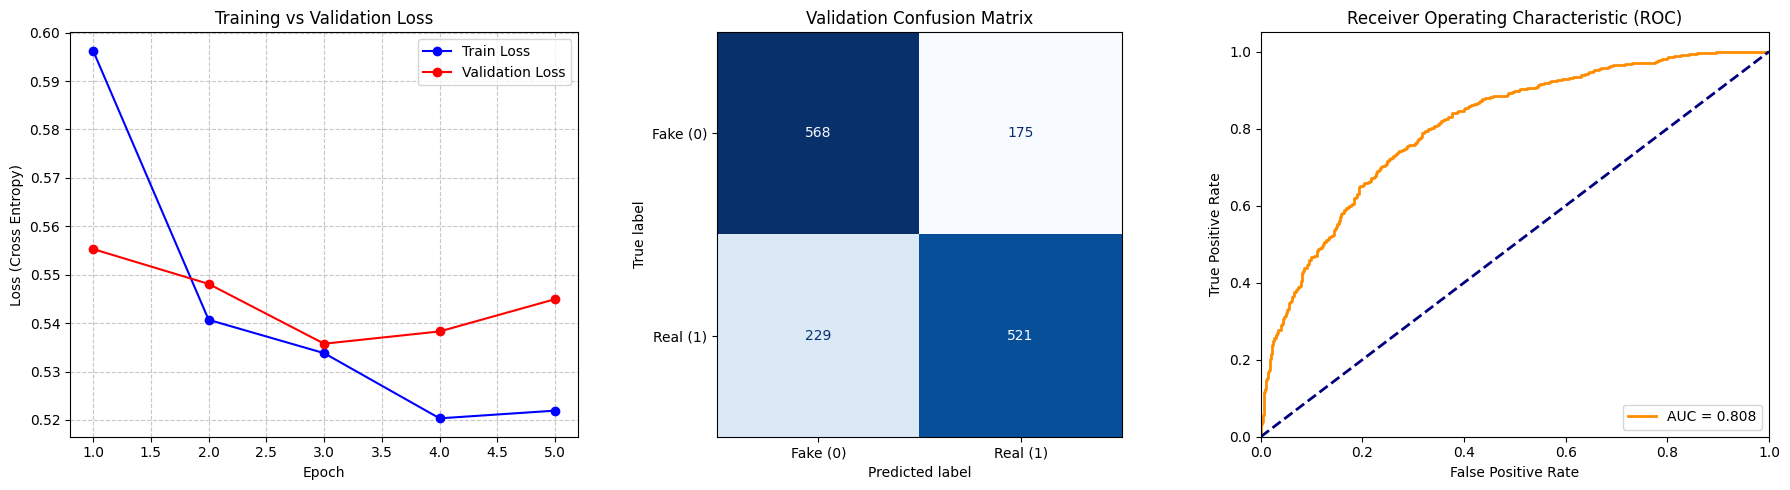

In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay

EPOCHS = 5
best_val_loss = float('inf')

train_losses, val_losses = [], []
all_true_labels, all_pred_probs, all_pred_classes = [], [], []

print(f"Starting Training Loop for {EPOCHS} Epochs...\n")

for epoch in range(EPOCHS):
    # TRAINING LOOP
    model.train()
    running_train_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # VALIDATION LOOP
    model.eval()
    running_val_loss = 0.0

    epoch_true = []
    epoch_probs = []
    epoch_preds = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)

            # Utilizing F.softmax for maximum numerical stability convention
            probs = F.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            epoch_true.extend(labels.cpu().numpy())
            epoch_probs.extend(probs.cpu().numpy())
            epoch_preds.extend(preds.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # METRICS CALCULATION
    val_acc = accuracy_score(epoch_true, epoch_preds)
    val_f1 = f1_score(epoch_true, epoch_preds)

    # Defensive check against single class batch collapse
    if len(set(epoch_true)) > 1:
        val_auc = roc_auc_score(epoch_true, epoch_probs)
    else:
        val_auc = 0.5000

    # Printing the full suite of metrics
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Val AUC: {val_auc:.4f}")

    # Save the absolute best weights based on validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), '/content/best_b2_sandbox.pth')

        # Lock in these predictions for the final graphs
        all_true_labels = epoch_true
        all_pred_probs = epoch_probs
        all_pred_classes = epoch_preds

print("\nTraining Complete. Best model saved to '/content/best_b2_sandbox.pth'")

# REPORT GRAPHS
print("\nGenerating visual assets for the report...")

if len(set(all_true_labels)) > 1:
    final_auc = roc_auc_score(all_true_labels, all_pred_probs)
else:
    final_auc = 0.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph A - Loss Curve
axes[0].plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o', color='blue')
axes[0].plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='o', color='red')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Cross Entropy)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Graph B - Confusion Matrix
cm = confusion_matrix(all_true_labels, all_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake (0)', 'Real (1)'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Validation Confusion Matrix')

# Graph C - ROC Curve
fpr, tpr, _ = roc_curve(all_true_labels, all_pred_probs)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {final_auc:.3f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Receiver Operating Characteristic (ROC)')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

05 - Test Run - No Training / No Weight Updates. Test.

Initiating Phase 4: Uncompromised Test Set Evaluation...

Loading optimal model weights...
Running unseen images through the EfficientNet-B2 pipeline...

FINAL TEST SET METRICS (UNSEEN DATA)
              precision    recall  f1-score   support

    Fake (0)     0.7083    0.7686    0.7372       752
    Real (1)     0.7464    0.6827    0.7131       750

    accuracy                         0.7257      1502
   macro avg     0.7273    0.7256    0.7252      1502
weighted avg     0.7273    0.7257    0.7252      1502

Absolute ROC-AUC Score: 0.8100



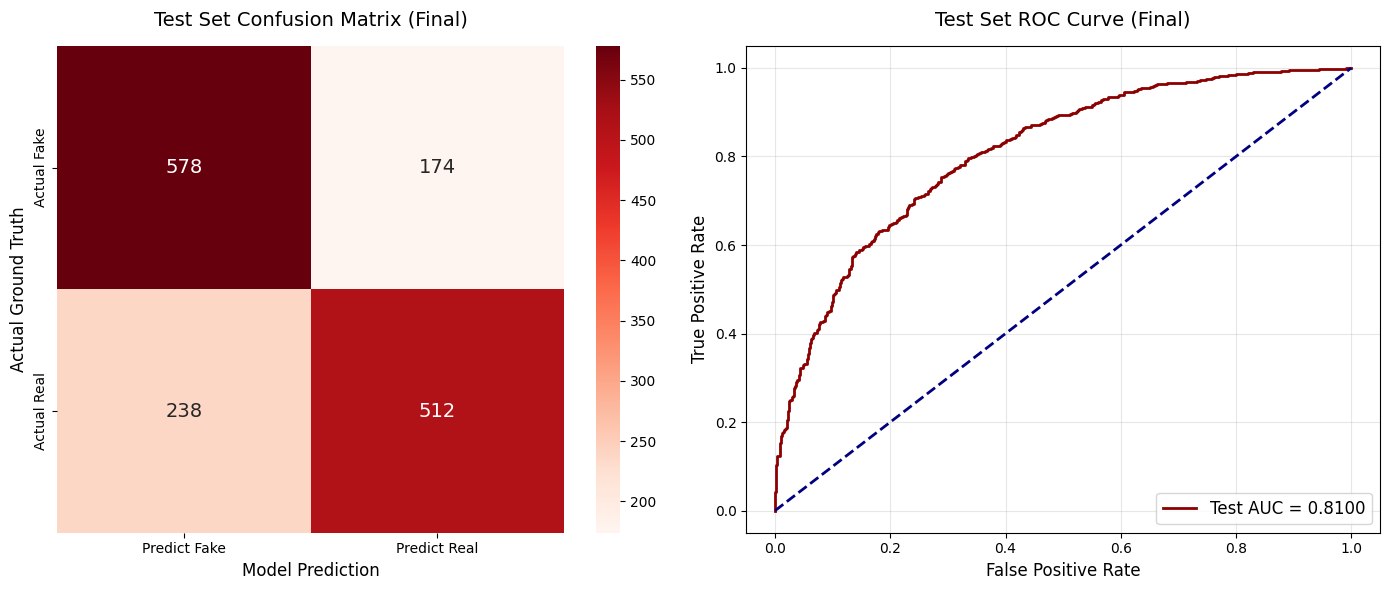

In [6]:
import torch
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("Initiating Phase 4: Uncompromised Test Set Evaluation...\n")

# 1. Load the best saved weights
weight_path = 'best_b2_sandbox.pth'
if not os.path.exists(weight_path):
    raise FileNotFoundError(f"CRITICAL: Could not find {weight_path}. Did the training cell save it?")

print("Loading optimal model weights...")
state_dict = torch.load(weight_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

test_preds = []
test_trues = []
test_probs = []

print("Running unseen images through the EfficientNet-B2 pipeline...")

# 2. Disable gradients and execute inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        # Convert labels to long - standard PyTorch practice for class indices
        labels = labels.to(device).view(-1).long()

        # Get raw logits from the 2-node head
        outputs = model(inputs)

        # DEFENSIVE TRIPWIRE: Ensure the model is actually outputting [batch_size, 2]
        if outputs.ndim != 2 or outputs.size(1) != 2:
            raise ValueError(f"CRITICAL: Expected model output shape [batch_size, 2], got {tuple(outputs.shape)}. Is the custom head missing?")

        # Convert to probabilities using Softmax.
        # [:, 1] extracts the probability specifically for Class 1 (Real) for the AUC calculation.
        probs = torch.softmax(outputs, dim=1)[:, 1]

        # Get the final prediction (0 or 1) by choosing the node with the highest probability
        preds = torch.argmax(outputs, dim=1).long()

        test_preds.extend(preds.cpu().numpy().tolist())
        test_trues.extend(labels.cpu().numpy().tolist())
        test_probs.extend(probs.cpu().numpy().tolist())

# Convert once for memory safety
test_preds = np.array(test_preds)
test_trues = np.array(test_trues)
test_probs = np.array(test_probs)

# 3. Metrics Calculation
conf_matrix = confusion_matrix(test_trues, test_preds)

has_two_classes = len(np.unique(test_trues)) == 2
if has_two_classes:
    test_auc = roc_auc_score(test_trues, test_probs)
else:
    test_auc = None

print("\n" + "="*40)
print("FINAL TEST SET METRICS (UNSEEN DATA)")
print("="*40)
print(classification_report(
    test_trues,
    test_preds,
    target_names=['Fake (0)', 'Real (1)'],
    digits=4,
    zero_division=0
))

if test_auc is not None:
    print(f"Absolute ROC-AUC Score: {test_auc:.4f}")
else:
    print("Absolute ROC-AUC Score: Undefined (test set contains only one class)")
print("="*40 + "\n")

# 4. Generate Final Report Assets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=axes[0],
    xticklabels=['Predict Fake', 'Predict Real'],
    yticklabels=['Actual Fake', 'Actual Real'],
    annot_kws={"size": 14}
)
axes[0].set_title('Test Set Confusion Matrix (Final)', fontsize=14, pad=15)
axes[0].set_xlabel('Model Prediction', fontsize=12)
axes[0].set_ylabel('Actual Ground Truth', fontsize=12)

if test_auc is not None:
    fpr, tpr, _ = roc_curve(test_trues, test_probs)
    axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'Test AUC = {test_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('Test Set ROC Curve (Final)', fontsize=14, pad=15)
    axes[1].legend(loc="lower right", fontsize=12)
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'ROC curve unavailable\n(only one class in test set)',
                 ha='center', va='center', fontsize=12)
    axes[1].set_title('Test Set ROC Curve (Final)', fontsize=14, pad=15)
    axes[1].axis('off')

plt.tight_layout()
plt.show()